In [1]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch --index-url https://download.pytorch.org/whl/cu126
!nvidia smi

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached https://download-r2.pytorch.org/whl/cu126/torch-2.12.1%2Bcu126-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached https://download.pytorch.org/whl/cu126/cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 41.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 46.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 46.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 46.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 46.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 47.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 43.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install "transformers==4.55.4" accelerate sentencepiece

In [4]:
import torch

In [5]:
gpu = torch.device("cuda")

In [6]:
!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "salihseferovic/bosnian-news-articles-dataset-from-klixba",
    "v2-klix_df.csv",
)
print("First 5 records:", df.head())

First 5 records:                                                title  \
0  Ukrajinski piloti započeli obuku za upravljanj...   
1  Košarkaši BiH se danas protiv Poljske bore za ...   
2  Nakon više od 80 godina Kaliforniji se sprema ...   
3  Kremlj je na popis stranih agenata u Rusiji uv...   
4  Savo Manojlović odgovorio Ani Brnabić: Da li s...   

                                                link article_class  \
0  https://www.klix.ba/vijesti/svijet/ukrajinski-...       vijesti   
1  https://www.klix.ba/sport/kosarka/kosarkasi-bi...         sport   
2  https://www.klix.ba/vijesti/svijet/nakon-vise-...       vijesti   
3  https://www.klix.ba/vijesti/svijet/kremlj-je-n...       vijesti   
4  https://www.klix.ba/vijesti/regija/savo-manojl...       vijesti   

         article_class_name  num_of_comments  num_of_shares  \
0   Obučavaju ih Amerikanci                0              0   
1  Finale pretkvalifikacija                8              0   
2             Uragan Hilary         

In [7]:
df.dtypes

title                 object
link                  object
article_class         object
article_class_name    object
num_of_comments        int64
num_of_shares          int64
picture_path          object
text                  object
date                  object
dtype: object

In [8]:
print(f"Ukupno clanaka: {len(df):,}")
#print(f"Broj kategorija (article_class_name): {df['article_class_name'].nunique()}")
print(f"Broj kategorija (article_class): {df['article_class'].nunique()}")

print("\n===== article_class =====")
print(df['article_class'].value_counts(dropna=False).to_string())

print("\n===== mapping article_class -> article_class_name =====")
print(
    df[['article_class']]
    .drop_duplicates()
    .sort_values('article_class')
    .to_string(index=False)
)

print("\n===== missing values po koloni =====")
print(df.isna().sum().to_string())

print("\n===== raspon datuma =====")
print("min:", df['date'].min(), "| max:", df['date'].max())

Ukupno clanaka: 786,755
Broj kategorija (article_class): 7

===== article_class =====
article_class
vijesti      385786
sport        171015
magazin      104455
biznis        48345
lifestyle     38332
scitech       22148
auto          16400
NaN             274

===== mapping article_class -> article_class_name =====
article_class
         auto
       biznis
    lifestyle
      magazin
      scitech
        sport
      vijesti
          NaN

===== missing values po koloni =====
title                     0
link                      0
article_class           274
article_class_name      274
num_of_comments           0
num_of_shares             0
picture_path          20960
text                      0
date                      0

===== raspon datuma =====
min: 2002-12-07 | max: 2023-08-20


In [9]:
df.head()

,title,link,article_class,article_class_name,num_of_comments,num_of_shares,picture_path,text,date
0,Ukrajinski piloti započeli obuku za upravljanj...,https://www.klix.ba/vijesti/svijet/ukrajinski-...,vijesti,Obučavaju ih Amerikanci,0,0,https://static.klix.ba/media/images/vijesti/b_...,Ukrajinski piloti započeli su zajedničku obuku...,2023-08-20
1,Košarkaši BiH se danas protiv Poljske bore za ...,https://www.klix.ba/sport/kosarka/kosarkasi-bi...,sport,Finale pretkvalifikacija,8,0,https://static.klix.ba/media/images/vijesti/b_...,Košarkaška reprezentacija Bosne i Hercegovine ...,2023-08-19
2,Nakon više od 80 godina Kaliforniji se sprema ...,https://www.klix.ba/vijesti/svijet/nakon-vise-...,vijesti,Uragan Hilary,17,18,https://static.klix.ba/media/images/vijesti/b_...,Uragan Hilary koji se kreće prema pacifičkoj o...,2023-08-19
3,Kremlj je na popis stranih agenata u Rusiji uv...,https://www.klix.ba/vijesti/svijet/kremlj-je-n...,vijesti,Paranoja u Moskvi,4,27,https://static.klix.ba/media/images/vijesti/23...,Rusko ministarstvo pravde uključilo je na tako...,2023-08-19
4,Savo Manojlović odgovorio Ani Brnabić: Da li s...,https://www.klix.ba/vijesti/regija/savo-manojl...,vijesti,Pitanje odgovornosti,8,8,https://static.klix.ba/media/images/vijesti/b_...,"Direktor pokreta ""Kreni-Promeni"" Savo Manojlov...",2023-08-19


In [10]:
import time
import numpy as np

_diac = str.maketrans({"š":"s","đ":"dj","č":"c","ć":"c","ž":"z","Š":"s","Đ":"dj","Č":"c","Ć":"c","Ž":"z"})
N_CHARS = 2500
CHUNK = 100000
n = len(df)
search = np.empty(n, dtype=object)
t0 = time.time()

for lo in range(0, n, CHUNK):
    hi = min(lo + CHUNK, n)
    b = (df["title"].iloc[lo:hi].fillna("") + " . "
         + df["text"].iloc[lo:hi].fillna("").str.slice(0, N_CHARS))
    search[lo:hi] = b.str.translate(_diac).str.lower().values
    el = time.time() - t0
    print(f"{hi:,}/{n:,} | {el:.0f}s | ~{el/hi*(n-hi):.0f}s preostalo")

df["_search"] = search
print(f"\nCache spreman za {n:,} clanaka ({time.time()-t0:.0f}s).")

100,000/786,755 | 9s | ~62s preostalo
200,000/786,755 | 18s | ~53s preostalo
300,000/786,755 | 27s | ~43s preostalo
400,000/786,755 | 35s | ~34s preostalo
500,000/786,755 | 43s | ~25s preostalo
600,000/786,755 | 50s | ~16s preostalo
700,000/786,755 | 57s | ~7s preostalo
786,755/786,755 | 63s | ~0s preostalo

Cache spreman za 786,755 clanaka (63s).


In [11]:
import numpy as np

NR_KEYWORDS = {
    "lithium":      [r"litij", r"\blopare\b", r"rio tinto", r"arcore"],
    "mining":       [r"rudnik", r"rudnic", r"\brudar", r"\bruda\b", r"\brude\b", r"\brudu\b", r"rudac", r"rudno blago", r"koncesij", r"povrsinski kop", r"\bkopov"],
    "bauxite":      [r"boksit"],
    "coal":         [r"\bugalj\b", r"\buglja\b", r"ugljen", r"ugljenokop", r"termoelektran", r"\brmu\b", r"lignit"],
    "iron_steel":   [r"zeljezn", r"zeljezar", r"\bcelik", r"\bcelicn", r"arcelormittal"],
    "base_metals":  [r"\bbakar\b", r"\bbakra\b", r"\bcinka\b", r"rudnik cink", r"\bolov[ao]\b"],
    "hydropower":   [r"hidroelektran", r"hidroenergij", r"hidropotencijal", r"hidroakumulacij"],
    "wind":         [r"vjetroelektran", r"vjetropark", r"vjetroenergij", r"energij vjetra"],
    "solar":        [r"solarn", r"fotonapon", r"suncev.{0,3}energij"],
    "gas":          [r"prirodni plin", r"plinovod", r"plinsk", r"zemni plin", r"gasovod"],
    "oil":          [r"\bnafta\b", r"\bnafte\b", r"naftn", r"naftovod"],
    "salt":         [r"rudnik soli", r"solana", r"tuzlansk.{0,12}sol"],
    "forest_wood":  [r"sumarstv", r"\bdrvn", r"drvoprer", r"sjeca sum", r"drvna industrij", r"\btrupc"],
    "water_res":    [r"vodni resurs", r"vodoprivred", r"vodosnabdij"],
    "agriculture":  [r"poljoprivredn.{0,3}zemljist", r"obradiv.{0,3}zemljist", r"\boranic"],
    "renewables":   [r"obnovljiv.{0,3}izvor", r"obnovljiv.{0,3}energij"],
}

all_terms = "|".join(t for terms in NR_KEYWORDS.values() for t in terms)
mask = df["_search"].str.contains(all_terms, regex=True)
df_nr = df.loc[mask].copy()

In [12]:
import pandas as pd

hits = pd.DataFrame({topic: df_nr["_search"].str.contains("|".join(terms), regex=True)
                     for topic, terms in NR_KEYWORDS.items()}, index=df_nr.index)
topic_names = np.array(list(NR_KEYWORDS))
df_nr["nr_topics"] = [list(topic_names[row]) for row in hits.values]
df_nr["nr_topic_count"] = hits.values.sum(axis=1)

print(f"Filtrirano: {len(df_nr):,} / {len(df):,} ({len(df_nr)/len(df)*100:.2f}%)")
print("\n--- po originalnoj kategoriji ---")
print(df_nr["article_class"].value_counts(dropna=False).to_string())
print("\n--- po resource topiku ---")
print(hits.sum().sort_values(ascending=False).to_string())
print("\n--- primjeri naslova po topiku ---")
for topic in NR_KEYWORDS:
    titles = df_nr.loc[df_nr["nr_topics"].apply(lambda x: topic in x), "title"].head(4).tolist()
    print(f"\n[{topic}]  n={int(hits[topic].sum())}")
    for t in titles:
        print("   -", t)

Filtrirano: 55,579 / 786,755 (7.06%)

--- po originalnoj kategoriji ---
article_class
vijesti      24566
sport        15188
biznis        9543
magazin       1994
lifestyle     1752
scitech       1420
auto          1085
NaN             31

--- po resource topiku ---
iron_steel     24033
mining         11216
oil             6937
gas             4862
coal            4737
forest_wood     2777
water_res       2336
hydropower      1663
base_metals     1584
solar           1537
renewables      1169
salt             880
lithium          818
agriculture      811
wind             306
bauxite          181

--- primjeri naslova po topiku ---

[lithium]  n=818
   - Savo Manojlović odgovorio Ani Brnabić: Da li ste premijerka Srbije ili Rio Tinta?
   - Crkva Svetog Preobraženja na Pofalićima obilježila krsnu slavu, prisustvovao veliki broj vjernika
   - Električni hiperautomobil Pininfarina B95 košta 4,4 miliona eura, isporučuje  1.874 KS
   - Brnabić objavila "besjedu" na stranici vlade Srbije i lid

In [13]:
import time

_diac = str.maketrans({"š":"s","đ":"dj","č":"c","ć":"c","ž":"z","Š":"s","Đ":"dj","Č":"c","Ć":"c","Ž":"z"})
N_LEAD = 200
CHUNK = 200000
n = len(df)
lead = np.empty(n, dtype=object)
t0 = time.time()

for lo in range(0, n, CHUNK):
    hi = min(lo + CHUNK, n)
    b = (df["title"].iloc[lo:hi].fillna("") + " . "
         + df["text"].iloc[lo:hi].fillna("").str.slice(0, N_LEAD))
    lead[lo:hi] = b.str.translate(_diac).str.lower().values
    print(f"{hi:,}/{n:,} | {time.time()-t0:.0f}s")

df["_lead"] = lead
print("Gotovo.")

200,000/786,755 | 3s
400,000/786,755 | 7s
600,000/786,755 | 10s
786,755/786,755 | 12s
Gotovo.


In [14]:
NR_KEYWORDS = {
    # Strogo definisani padeži za litij/litijum (jednina). Izbačeni nastavci -e, -ama (litije)
    "lithium":      [r"\blitij(a|u|em)?\b", r"\blitijum(a|u|om)?\b", r"\blopar(a|e|i|u|om|ama)?\b", r"rio tinto", r"arcore", r"jadarit"],
    
    # Rudarstvo - obuhvata rudnike, rudare i izvedene pridjeve u svim padežima
    "mining":       [r"\brudnik(a|u|e|om|i|ima)?\b", r"\brudnic(i|ima)?\b", r"\brudarstv(o|a|u|om)?\b", r"\brudarsk(i|og|om|im|ih|a|e|o)?\b", r"\brudar(a|i|e|ima|om)?\b", r"povrsinsk.{0,3}kop", r"eksploatacij.{0,15}(rud|mineral|ugalj)", r"koncesij.{0,15}(rud|mineral)"],
    
    "bauxite":      [r"\bboksit(a|u|om|i)?\b"],
    
    # Ugalj - ugalj/uglja/uglju/ugljem i oblici za lignit i elektrane
    "coal":         [r"\bugalj\b", r"\buglj(a|u|em|i|e|ima)?\b", r"\bugljenokop(a|u|i|e|om|ima)?\b", r"\btermoelektran(a|e|i|u|om|ama)?\b", r"\brmu\b", r"\blignit(a|u|om)?\b", r"rudnik.{0,10}uglja"],
    
    # Željezo i čelik (podržava i kvačice č/ž i ošišanu latinicu c/z)
    "iron_steel":   [r"\b(ž|z)eljezar(a|e|i|u|om|ama)?\b", r"\b(ž|z)eljezn(i|og|om|ih|im|a|e|o)?\b.{0,4}rud", r"arcelormittal", r"\b(č|c)elik(a|u|om)?\b", r"\b(č|c)eli(č|c)n(i|og|om|ih|im|a|e|o)?\b", r"proizvodnj.{0,10}(č|c)elik"],
    
    # Baza metala - bakar/bakra/bakru + Vareš unutar konteksta
    "base_metals":  [r"rudnik.{0,10}(cink|olov|bakr)", r"\bbakar\b", r"\bbakr(a|u|om)?\b", r"olov.{0,5}cink", r"cink.{0,5}olov", r"eastern mining", r"\bvares\b.{0,20}(rudnik|mining|cink|olov|srebr)"],
    
    "hydropower":   [r"\bhidroelektran(a|e|i|u|om|ama)?\b", r"hidroenergij", r"hidropotencijal", r"hidroakumulacij"],
    
    "wind":         [r"\bvjetroelektran(a|e|i|u|om|ama)?\b", r"vjetropark", r"vjetroenergij", r"energij.{0,3}vjetra"],
    
    "solar":        [r"\bsolarn(i|og|om|ih|im|a|e|o)?\b.{0,4}(elektran|panel|energij|park)", r"fotonapon", r"fotovoltaik"],
    
    "gas":          [r"prirodn.{0,4}plin", r"plinovod", r"zemni plin", r"gasovod", r"\bbh gas\b", r"\bgasn(i|og|om|ih|im|a|e|o)?\b.{0,4}(operater|mreza)"],
    
    "oil":          [r"\bnaft(a|e|i|u|om)?\b", r"\bnaftovod(a|u|om|i)?\b", r"\brafinerij(a|e|i|u|om|ama)?\b"],
    
    "salt":         [r"rudnik soli", r"\bsolan(a|e|i|u|om|ama)?\b", r"tuzlansk.{0,12}sol", r"proizvodnj.{0,6}soli"],
    
    # Šume i drvo - sprečava da riječ "drvo" (udaljeno) hvata nevezane stvari
    "forest_wood":  [r"\bdrvn(i|og|om|ih|im|a|e|o)?\b.{0,4}industrij", r"\bdrvoprer(ad|o)?\w*\b", r"sjec.{0,4}sum", r"krcenj.{0,4}sum", r"\btrupc(i|a|e|ima)?\b", r"eksploatacij.{0,6}sum", r"\b(š|s)umsk(i|og|om|ih|im|a|e|o)?\b.{0,4}(pozar|fond|gazdinstv)", r"bespravn.{0,4}sjec"],
    
    "water_res":    [r"vodni resurs", r"vodosnabdijevanj", r"izvoris.{0,4}vode", r"hidroakumulacij", r"rijecn.{0,4}sliv"],
    
    "agriculture":  [r"poljoprivredn.{0,4}zemljist", r"obradiv.{0,4}zemljist", r"\boranic(a|e|i|u|om|ama)?\b"],
    
    "renewables":   [r"obnovljiv.{0,4}izvor", r"obnovljiv.{0,4}energij"],
}

def _nc(terms):
    return "|".join(terms).replace("(", "(?:")

base = df[df["article_class"] != "sport"]
all_terms = _nc([t for terms in NR_KEYWORDS.values() for t in terms])
mask = base["_lead"].str.contains(all_terms, regex=True)
df_nr = base.loc[mask].copy()

hits = pd.DataFrame({topic: df_nr["_lead"].str.contains(_nc(terms), regex=True)
                     for topic, terms in NR_KEYWORDS.items()}, index=df_nr.index)


base = df[df["article_class"] != "sport"]
all_terms = "|".join(t for terms in NR_KEYWORDS.values() for t in terms)

bih_terms = (
    r"\bbih\b|bosn.{1,4}\s+i\s+hercegov|republik.{1,4}\s+srpsk|\brs\b|\bfbih\b|federacij.{1,4}\s+bih|" # Država/Entiteti
    r"unsko-sanski|posavsk|tuzlansk|zeničko|zenicko|bosansko-podrinjsk|srednjobosansk|hercegovačko|hercegovacko|zapadnohercegovačk|zapadnohercegovack|livanjsk|\bkanton|" # Kantoni
    r"sarajev|banj.{1,3}\s*luk|tuzl|zenic|mostar|bijeljin|br[cč]|prijedor|doboj|trebin|biha[cć]|bugojn|jajc|livn|cazin|gradi[sš]|zvornik|živin|zivin|gra[cč]an|te[sš]anj|" # Gradovi
    r"kakanj|banovi[cć]|đurđev|djurdjev|durdev|ugljevik|gacko|stanar|omarsk|srebrenic|kreka|miljevin|kamengrad|vare[sš]|lopar" # Poznata nalazišta i rudnici
)

mask_resource = base["_lead"].str.contains(all_terms, regex=True)
mask_bih = base["_lead"].str.contains(bih_terms, regex=True, case=False)

df_nr = base.loc[mask_resource & mask_bih].copy()

hits = pd.DataFrame({topic: df_nr["_lead"].str.contains("|".join(terms), regex=True)
                     for topic, terms in NR_KEYWORDS.items()}, index=df_nr.index)
topic_names = np.array(list(NR_KEYWORDS))
df_nr["nr_topics"] = [list(topic_names[row]) for row in hits.values]
df_nr["nr_topic_count"] = hits.values.sum(axis=1)

market_terms = r"cijen|poskupljenj|pojeftin|fening|barel|\bberz|akciz|po litri"
df_nr["is_market_news"] = df_nr["_lead"].str.contains(market_terms, regex=True)
print("market/price clanaka:", int(df_nr["is_market_news"].sum()))

print(f"Filtrirano: {len(df_nr):,} / {len(df):,} (sport izbacen)")
print("\n--- po originalnoj kategoriji ---")
print(df_nr["article_class"].value_counts(dropna=False).to_string())
print("\n--- po resource topiku ---")
print(hits.sum().sort_values(ascending=False).to_string())
print("\n--- primjeri naslova po topiku ---")
for topic in NR_KEYWORDS:
    titles = df_nr.loc[df_nr["nr_topics"].apply(lambda x: topic in x), "title"].head(5).tolist()
    print(f"\n[{topic}]  n={int(hits[topic].sum())}")
    for t in titles:
        print("   -", t)

/tmp/ipykernel_519/1224502578.py:63: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_resource = base["_lead"].str.contains(all_terms, regex=True)
/tmp/ipykernel_519/1224502578.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = pd.DataFrame({topic: df_nr["_lead"].str.contains("|".join(terms), regex=True)


market/price clanaka: 350
Filtrirano: 4,766 / 786,755 (sport izbacen)

--- po originalnoj kategoriji ---
article_class
vijesti      3055
biznis       1640
magazin        47
lifestyle      12
auto            6
scitech         5
NaN             1

--- po resource topiku ---
mining         1911
coal           1009
iron_steel      666
oil             445
hydropower      329
forest_wood     281
water_res       225
gas             182
salt            147
lithium         109
renewables       87
wind             78
base_metals      69
solar            66
agriculture      65
bauxite          33

--- primjeri naslova po topiku ---

[lithium]  n=109
   - U dijelovima RS proglašeno vanredno stanje zbog afričke svinjske kuge, u BiH stiže ekspertski tim
   - Pozadina priče o stolaru koji proizvodnju iz FBiH seli u RS: U sve se upliću nacionalizam i politika
   - Sanja Lopar, prva žena u Evropi koja proizvodi cigare: Imaju aromu Trebevića i kafe s Baščaršije
   - Policija u Loparama uhapsila muškarca

In [15]:
!pip install "transformers==4.55.4"

In [16]:
import torch, json
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL = "Qwen/Qwen3-4B-Instruct-2507"
tok = AutoTokenizer.from_pretrained(MODEL)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"
model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.bfloat16, device_map="cuda").eval()

SYS = """Ti si filter za bazu vijesti o prirodnim resursima u BiH i regionu. Za svaki clanak (naslov + pocetak teksta) odluci da li je STVARNO o prirodnim resursima: rudarstvo, rude i minerali (litij, boksit, zeljezo, cink, olovo, bakar), ugalj i termoenergetika, nafta i plin (UKLJUCUJUCI cijene goriva i trzista), hidro/vjetar/solar i obnovljivi izvori, sumarstvo i drvna industrija, vodni resursi, poljoprivredno zemljiste, te povezane kompanije, projekti, koncesije, investicije i politika u tom sektoru.

NIJE relevantno (relevantno=false):
- sportski klubovi nazvani po resursima (FK Celik, Zeljeznicar, Rudar)
- namjenska/vojna industrija i proizvodnja oruzja i municije (npr. Binas, Zrak, BNT, Vitezit, Pretis, Igman, Ginex)
- opsta preradjivacka, masinska, prehrambena ili tehnoloska industrija koja NIJE vezana za eksploataciju prirodnih resursa ili energetiku
- metafore, usputni spomen jedne rijeci, lifestyle/zabava/horoskop, kriminal i nesrece bez veze s resursnim sektorom, gradovi/imena koja se slucajno poklapaju (npr. grad Olovo)

PAZNJA: zeljezara, celicana i metalurgija vezana za rude i metale (npr. ArcelorMittal Zenica) OSTAJU relevantni jer su dio resursnog lanca.

Vrati ISKLJUCIVO JSON, bez ikakvog drugog teksta:
{"relevantno": true ili false, "tema": "<jedna od: lithium, mining, bauxite, coal, iron_steel, base_metals, hydropower, wind, solar, gas, oil, salt, forest_wood, water_res, agriculture, renewables, none>"}

PRIMJERI:
Naslov: "Celik se u 98. minuti spasio neocekivanog poraza" -> {"relevantno": false, "tema": "none"}
Naslov: "Helez i Niksic posjetili Binas u Bugojnu: podrska namjenskoj industriji" -> {"relevantno": false, "tema": "none"}
Naslov: "Premasen plan proizvodnje Rudnika boksita Srebrenica" -> {"relevantno": true, "tema": "bauxite"}
Naslov: "ArcelorMittal Zenica najavio modernizaciju zeljezare" -> {"relevantno": true, "tema": "iron_steel"}
Naslov: "Glumica ponosno pokazala trudnicki stomak" -> {"relevantno": false, "tema": "none"}
Naslov: "Nove cijene goriva na pumpama u Sarajevu" -> {"relevantno": true, "tema": "oil"}
Naslov: "Na podrucju Konjica gradi se vjetroelektrana od 200 miliona KM" -> {"relevantno": true, "tema": "wind"}"""

def build_user(title, text):
    return f'Naslov: "{title}"\nTekst: "{(text or "")[:600]}"'

def parse(txt):
    try:
        s = txt[txt.index("{"): txt.rindex("}") + 1]
        d = json.loads(s)
        return bool(d.get("relevantno", False)), str(d.get("tema", "none"))
    except Exception:
        return None, "parse_error"

titles = list(df_nr["title"].fillna(""))
texts = list(df_nr["text"].fillna(""))
raw = []
BS = 64
for i in range(0, len(titles), BS):
    msgs = [[{"role": "system", "content": SYS},
             {"role": "user", "content": build_user(t, x)}]
            for t, x in zip(titles[i:i+BS], texts[i:i+BS])]
    prompts = [tok.apply_chat_template(m, tokenize=False, add_generation_prompt=True) for m in msgs]
    enc = tok(prompts, return_tensors="pt", padding=True, truncation=True, max_length=1600).to("cuda")
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=80, do_sample=False, pad_token_id=tok.pad_token_id)
    gen = out[:, enc["input_ids"].shape[1]:]
    raw.extend(tok.batch_decode(gen, skip_special_tokens=True))
    print(f"{min(i+BS, len(titles)):,}/{len(titles):,}")

parsed = [parse(r) for r in raw]
df_nr["llm_relevant"] = [r for r, _ in parsed]
df_nr["llm_topic"] = [t for _, t in parsed]
df_final = df_nr[df_nr["llm_relevant"] != False].copy()

print(f"\nLLM zadrzao: {(df_nr['llm_relevant']==True).sum():,}")
print(f"LLM izbacio: {(df_nr['llm_relevant']==False).sum():,}")
print(f"Parse errori: {df_nr['llm_relevant'].isna().sum():,}")
print("\n--- nova tema raspodjela ---")
print(df_final["llm_topic"].value_counts().to_string())
print("\n--- primjeri sta je IZBACIO ---")
for t in df_nr.loc[df_nr["llm_relevant"]==False, "title"].head(15):
    print("   -", t)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


64/4,766


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


128/4,766


...

4,608/4,766


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


4,672/4,766


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


4,736/4,766
4,766/4,766

LLM zadrzao: 3,823
LLM izbacio: 943
Parse errori: 0

--- nova tema raspodjela ---
llm_topic
coal               960
mining             549
oil                432
iron_steel         395
hydropower         324
water_res          247
gas                236
renewables         169
forest_wood        164
wind                72
solar               65
base_metals         51
agriculture         50
bauxite             42
salt                40
heat_energy         14
termoenergetika      4
heat_power           2
none                 2
wood                 2
lithium              1
aluminum             1
heat                 1

--- primjeri sta je IZBACIO ---
   - Helez, Nikšić i Lakić posjetili Binas u Bugojnu: Obećali podršku kompaniji i nova zapošljavanja
   - Grčka: Niko od državljana BiH do jutros nije tražio pomoć ambasade
   - Predstavnik RS-a sastao se sa direktorom UNESCO-a u Parizu u vezi hidroelektrane Buk Bijela
   - Muk u "Zraku": Nekadašnji gigant namjenske ind

In [25]:
for title in df_final["title"].head(500):
    print(title)

Ministar Lakić poručio Amerikancima: Agresivno ulazimo u energetsku tranziciju
Da li će vlade RS-a i Srbije nastaviti s ignorisanjem Ustavnog suda BiH po pitanju Buk Bijele?
Lakić: Ugalj nije budućnost, moramo tražiti sistemska rješenja
Rudari od Nikšića traže smjenu Uprave Elektroprivrede BiH
Okončani protesti ispred Elektroprivrede BiH u Sarajevu, rudarima se niko nije želio obratiti
Rudari pred zgradom Elektroprivrede BiH u Sarajevu, uzvikuju "lopovi, lopovi"
Veliki protesti rudara u Sarajevu: Nećemo se predati jer mi izbora nemamo
Danas protest rudara ispred Elektroprivrede BiH
Sinan Husić: Ako država bira te koji bi silu primjenili, halal joj bilo, ali ne daj im oružje, pucat će
U narednim danima gorivo u RS-u poskupljuje za 10 feninga
Elektroprivreda BiH odgovorila Nikšiću i Lakiću na zahtjev za hitnu isplatu plaća zeničkim rudarima
Rudari najavili masovne proteste 1. augusta ispred zgrade Elektroprivrede u Sarajevu
Zenički rudari još su pod zemljom: Hoće li sastanak u Vladi FBiH

#Recommender

In [17]:
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

df_final = df_nr[df_nr["llm_relevant"] != False].reset_index(drop=True)

_diac = str.maketrans({"š":"s","đ":"dj","č":"c","ć":"c","ž":"z","Š":"s","Đ":"dj","Č":"c","Ć":"c","Ž":"z"})
def normalize(t):
    t = (t or "").translate(_diac).lower()
    return re.sub(r"[^a-z\s]", " ", t)

BOS_STOP = ["a","ako","ali","bas","bez","bi","bih","bila","bili","bilo","bio","biti","bude","budu",
"ce","cemo","cete","cak","da","dakle","do","dok","dosta","druga","drugi","eto","gdje","hvala","i","iako",
"ide","ili","ima","imali","imam","imao","imati","iz","iza","izmedju","ja","je","jedan","jedna","jedno","jer",
"jos","kad","kada","kako","kao","koja","koje","koji","kojima","koju","kroz","li","me","medju","mene","meni",
"mi","moga","mogu","moj","moja","moje","mora","morao","mu","na","nad","nakon","nam","nama","nas","nasa",
"nase","nego","neka","neki","nekog","neko","nema","ni","nije","nikada","nisam","nista","niti","no","o","od",
"on","ona","oni","ono","ova","ovaj","ovako","ovamo","ovdje","ove","ovim","ovo","pa","pak","po","pod","pored",
"posto","prije","protiv","sa","sad","sada","samo","se","sebe","sebi","si","smo","ste","su","svaki","sve","svi",
"svim","svoj","svoja","svoje","ta","taj","tada","tako","tamo","te","tebe","tebi","ti","time","to","tu","tvoj",
"u","uz","vam","vama","vas","vasa","vec","vi","vise","za","zar","zato","zbog","sto"]

corpus = (df_final["title"].fillna("") + ". " + df_final["title"].fillna("") + ". " + df_final["text"].fillna("")).tolist()

tfidf = TfidfVectorizer(preprocessor=normalize, stop_words=BOS_STOP, ngram_range=(1,2),
                        min_df=2, max_df=0.5, sublinear_tf=True)
X = tfidf.fit_transform(corpus)

cvec = CountVectorizer(preprocessor=normalize, stop_words=BOS_STOP, ngram_range=(1,2),
                       min_df=2, max_df=0.5, binary=True)
Xbin = cvec.fit_transform(corpus)
bin_sum = np.asarray(Xbin.sum(axis=1)).ravel()

topics = df_final["llm_topic"].values
print("Korpus:", X.shape, "| vokabular:", len(tfidf.vocabulary_))

Korpus: (3823, 101820) | vokabular: 101820


In [18]:
from sklearn.metrics.pairwise import linear_kernel, euclidean_distances

def recommend(idx, k=5, metric="cosine"):
    if metric == "cosine":
        s = linear_kernel(X[idx], X).ravel()
        order = s.argsort()[::-1]
    elif metric == "euclidean":
        d = euclidean_distances(X[idx], X).ravel()
        s = -d
        order = d.argsort()
    elif metric == "jaccard":
        q = Xbin[idx]
        inter = np.asarray(q.dot(Xbin.T).todense()).ravel()
        union = bin_sum[idx] + bin_sum - inter
        s = np.divide(inter, union, out=np.zeros_like(inter, dtype=float), where=union > 0)
        order = s.argsort()[::-1]
    out = [j for j in order if j != idx][:k]
    return [(int(j), float(s[j])) for j in out]

In [19]:
import random

def category_match_rate(metric, k, sample=300, seed=42):
    rng = random.Random(seed)
    pool = [i for i in range(len(df_final)) if topics[i] not in ("none", "parse_error")]
    idxs = rng.sample(pool, min(sample, len(pool)))
    hits = total = 0
    for i in idxs:
        for j, _ in recommend(i, k=k, metric=metric):
            total += 1
            if topics[j] == topics[i]:
                hits += 1
    return hits / total if total else 0.0

print(f"{'metric':10s} {'k=3':>7s} {'k=5':>7s} {'k=10':>7s}")
for metric in ["cosine", "euclidean", "jaccard"]:
    rates = [category_match_rate(metric, k) for k in (3, 5, 10)]
    print(f"{metric:10s} " + " ".join(f"{r:7.3f}" for r in rates))

metric         k=3     k=5    k=10
cosine       0.744   0.721   0.680
euclidean    0.744   0.721   0.680
jaccard      0.710   0.691   0.644


In [29]:
MACRO = {
    "mining":"vadjenje","coal":"vadjenje","bauxite":"vadjenje","base_metals":"vadjenje",
    "iron_steel":"vadjenje","lithium":"vadjenje","salt":"vadjenje",
    "oil":"ugljovodonici","gas":"ugljovodonici",
    "solar":"obnovljivi","wind":"obnovljivi","hydropower":"obnovljivi","renewables":"obnovljivi",
    "water_res":"zemlja_voda","forest_wood":"zemlja_voda","agriculture":"zemlja_voda",
}
macro = np.array([MACRO.get(t, "ostalo") for t in topics])

def match_rate(metric, k, labels, sample=300, seed=42):
    rng = random.Random(seed)
    pool = [i for i in range(len(df_final)) if topics[i] not in ("none","parse_error")]
    idxs = rng.sample(pool, min(sample, len(pool)))
    hits = total = 0
    for i in idxs:
        for j, _ in recommend(i, k=k, metric=metric):
            total += 1
            if labels[j] == labels[i]:
                hits += 1
    return hits / total if total else 0.0

print("MAKRO grupe (4 kategorije):")
print(f"{'metric':10s} {'k=3':>7s} {'k=5':>7s} {'k=10':>7s}")
for metric in ["cosine", "jaccard"]:
    print(f"{metric:10s} " + " ".join(f"{match_rate(metric, k, macro):7.3f}" for k in (3, 5, 10)))

MAKRO grupe (4 kategorije):
metric         k=3     k=5    k=10
cosine       0.889   0.878   0.855
jaccard      0.863   0.855   0.833


In [20]:
def show(idx, k=5, metric="cosine"):
    print(f"QUERY  [{topics[idx]}]  {df_final.iloc[idx]['title']}\n")
    for j, sc in recommend(idx, k=k, metric=metric):
        print(f"  {sc:.3f}  [{topics[j]}]  {df_final.iloc[j]['title']}")

show(0, k=5, metric="cosine")

QUERY  [renewables]  Ministar Lakić poručio Amerikancima: Agresivno ulazimo u energetsku tranziciju

  0.116  [renewables]  Ambasador Norveške i predsjedavajući Tegeltija razgovarali o energetskim izazovima u BiH i regionu
  0.114  [renewables]  Isplati li se milijardu eura investirati u Blok 7 i šta su zaista obnovljivi izvori
  0.104  [renewables]  Nikšić razgovarao s predstavnicima EBRD-a: Južna interkonekcija nam je jedan od važnijih interesa
  0.103  [solar]  Ovo su najavljene olakšice za pravljenje solarnih elektrana u bh. domaćinstvima i firmama
  0.099  [renewables]  Džindić: Moramo zajedno raditi na pravednoj tranziciji za dobrobit naših građana


In [26]:
import pandas as pd
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity

dates = pd.to_datetime(df_final["date"], errors="coerce")
_rec = (dates - dates.min()).dt.days
recency = (_rec / _rec.max()).fillna(0.0).values

def diversify(cand, base, k=10, lam=0.5, tau=0.45, cap=4, beta=0.10):
    cand = list(cand)
    base = np.asarray(base, dtype=float) + beta * recency[cand]
    S = cosine_similarity(X[cand])
    n = len(cand)
    pen = np.zeros(n)
    dup = np.zeros(n)
    avail = list(range(n))
    chosen = []
    while len(chosen) < k and avail:
        a = np.array(avail)
        adj = np.where(dup[a] >= cap, -1e9, base[a] - lam * pen[a])
        b = int(a[int(np.argmax(adj))])
        chosen.append(cand[b])
        avail.remove(b)
        pen += S[b]
        dup += (S[b] > tau).astype(float)
    return chosen

def recommend_diverse(idx, k=10, pool=80, lam=0.5, tau=0.45, cap=4, beta=0.10):
    sims = linear_kernel(X[idx], X).ravel()
    sims[idx] = -1.0
    cand = np.argsort(sims)[::-1][:pool]
    return diversify(cand, sims[cand], k=k, lam=lam, tau=tau, cap=cap, beta=beta)

In [27]:
def titles_of(idxs):
    for j in idxs:
        print(f"  [{topics[j]}] {df_final.iloc[j]['title']}")

q = int(np.where(topics == "oil")[0][0])
print("BEZ diversity:")
titles_of([j for j, _ in recommend(q, k=10, metric="cosine")])
print("\nSA diversity (cap=4):")
titles_of(recommend_diverse(q, k=10))

BEZ diversity:
  [oil] U RS-u poskupljuje gorivo
  [oil] Gorivo u cijeloj BiH skuplje za dva do pet feninga, očekuje se i dalji rast
  [oil] Od danas gorivo na pumpama u RS-u jeftinije za pet feninga
  [oil] Cijene goriva u BiH dostigle rekord
  [oil] Od danas skuplje gorivo u FBiH
  [oil] Novo smanjenje cijena nafte
  [oil] Poskupljuju nafta i naftni derivati u FBiH
  [oil] FBiH: Cijene goriva neće rasti tokom vikenda
  [oil] Gorivo u RS-u skuplje za oko 10 feninga
  [oil] Od ponoći jeftinije gorivo u RS-u

SA diversity (cap=4):
  [oil] Od danas gorivo na pumpama u RS-u jeftinije za pet feninga
  [oil] Nezavisni blok nudi zakonsko rješenje kojim se smanjuje cijena nafte za 15 feninga po litri
  [oil] Cijene goriva u Federaciji BiH rastu, a u RS-u neće ni narednih 15 dana
  [oil] Cijene nafte na svjetskom tržištu i dalje padaju, u BiH bez većih promjena
  [oil] Višković: Republika Srpska je spremna na suspendovanje akciza na gorivo
  [oil] Poskupljuju nafta i naftni derivati u FBiH
  [

In [28]:
def homepage(k=12, per_topic_cap=3, lam=0.5, tau=0.25):
    eng = (df_final["num_of_comments"].fillna(0) + df_final["num_of_shares"].fillna(0)).values.astype(float)
    eng = eng / (eng.max() or 1)
    base = recency + 0.5 * eng
    cand = list(np.argsort(base)[::-1][:400])
    S = cosine_similarity(X[cand])
    pen = np.zeros(len(cand))
    avail = list(range(len(cand)))
    chosen, tcount = [], {}
    while len(chosen) < k and avail:
        a = np.array(avail)
        adj = base[[cand[i] for i in a]] - lam * pen[a]
        blocked = np.array([tcount.get(topics[cand[i]], 0) >= per_topic_cap for i in a])
        adj = np.where(blocked, -1e9, adj)
        if adj.max() <= -1e8:
            break
        b = int(a[int(np.argmax(adj))])
        ci = cand[b]
        chosen.append(ci)
        tcount[topics[ci]] = tcount.get(topics[ci], 0) + 1
        avail.remove(b)
        pen += S[b]
    return chosen

print("HOMEPAGE feed (cap 3 po temi):")
for j in homepage(k=12, per_topic_cap=3):
    print(f"  [{topics[j]}] {df_final.iloc[j]['title']}")

HOMEPAGE feed (cap 3 po temi):
  [oil] Građani BiH na Facebooku pozivaju na bojkot svih benzinskih pumpi za vikend
  [mining] Građani Sarajeva rudarima donose hranu i čajeve, pomoć pristigla i od studenata
  [mining] Radnici u Elektroprivredi protestuju zbog "neutemeljenih" zahtjeva rudara
  [hydropower] Zabranjena izgradnja malih hidroelektrana u Federaciji BiH!
  [coal] Hiljadu Tuzlaka na protestu ispred Kreke: Ako je rudarima mrak, neka onda bude svima
  [coal] Rudari u Banovićima iftarili u jami dubokoj 300 metara, pridružio im se i Fadil Novalić
  [coal] Izetbegović posjetio rudnik mrkog uglja u Kaknju, sišao u jamu s rudarima
  [hydropower] Još jedna pobjeda ekoloških aktivista u BiH: Poništena dozvola za gradnju dvije MHE na Neretvici
  [water_res] Veći dio Sarajeva satima bez vode, iz ViK-a saopćili kada se očekuje normalizacija vodosnabdijevanja
  [oil] U narednim danima gorivo u RS-u poskupljuje za 10 feninga
  [gas] Vijeće ministara BiH danas o izgradnji plinovoda, vanjskim 

#Model training and testing

In [30]:
import collections
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

y = np.array(topics)
counts = collections.Counter(y[~np.isin(y, ["none", "parse_error"])])
keep_cls = {c for c, n in counts.items() if n >= 15}
mask = np.isin(y, list(keep_cls))

Xc, yc = X[mask], y[mask]
print("Klase u klasifikaciji:", {c: counts[c] for c in sorted(keep_cls)})
print("Uzoraka:", Xc.shape[0])

Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)

models = {
    "NaiveBayes":   MultinomialNB(),
    "DecisionTree": DecisionTreeClassifier(max_depth=20, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}
for name, m in models.items():
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    print(f"{name:14s} acc={accuracy_score(yte, pred):.3f}  macroF1={f1_score(yte, pred, average='macro'):.3f}")

print("\nDT / RF po max_depth (PDF zahtjev):")
for md in [5, 10, 20, None]:
    dt = DecisionTreeClassifier(max_depth=md, random_state=42).fit(Xtr, ytr)
    rf = RandomForestClassifier(n_estimators=200, max_depth=md, random_state=42, n_jobs=-1).fit(Xtr, ytr)
    print(f"max_depth={str(md):>4s}  DT acc={accuracy_score(yte, dt.predict(Xte)):.3f}  RF acc={accuracy_score(yte, rf.predict(Xte)):.3f}")

Klase u klasifikaciji: {'agriculture': 50, 'base_metals': 51, 'bauxite': 42, 'coal': 960, 'forest_wood': 164, 'gas': 236, 'hydropower': 324, 'iron_steel': 395, 'mining': 549, 'oil': 432, 'renewables': 169, 'salt': 40, 'solar': 65, 'water_res': 247, 'wind': 72}
Uzoraka: 3796
NaiveBayes     acc=0.449  macroF1=0.234
DecisionTree   acc=0.736  macroF1=0.609
RandomForest   acc=0.834  macroF1=0.772

DT / RF po max_depth (PDF zahtjev):
max_depth=   5  DT acc=0.564  RF acc=0.373
max_depth=  10  DT acc=0.652  RF acc=0.523
max_depth=  20  DT acc=0.736  RF acc=0.678
max_depth=None  DT acc=0.787  RF acc=0.834


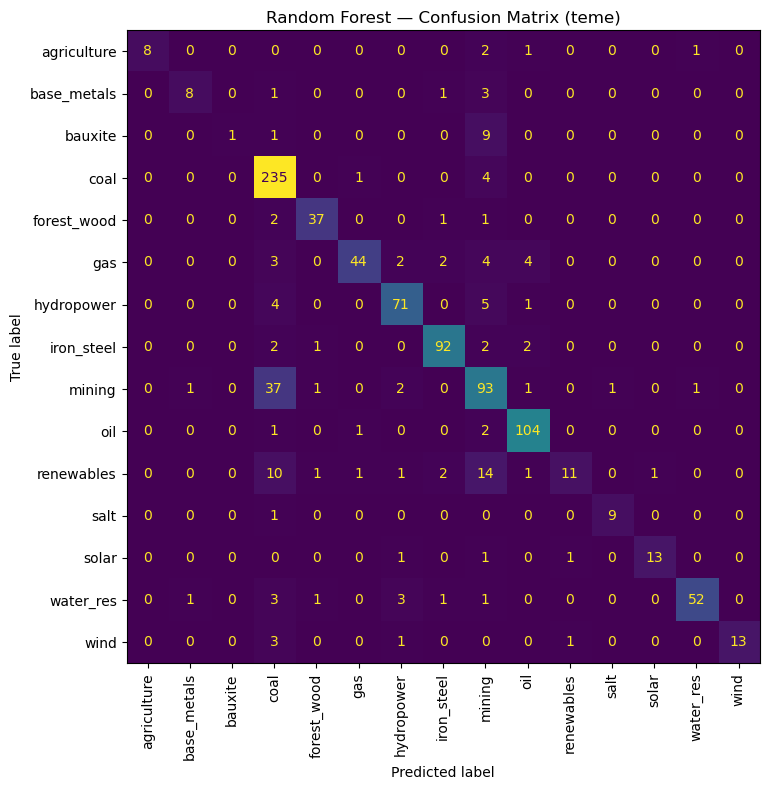

              precision    recall  f1-score   support

 agriculture       1.00      0.67      0.80        12
 base_metals       0.80      0.62      0.70        13
     bauxite       1.00      0.09      0.17        11
        coal       0.78      0.98      0.87       240
 forest_wood       0.90      0.90      0.90        41
         gas       0.94      0.75      0.83        59
  hydropower       0.88      0.88      0.88        81
  iron_steel       0.93      0.93      0.93        99
      mining       0.66      0.68      0.67       137
         oil       0.91      0.96      0.94       108
  renewables       0.85      0.26      0.40        42
        salt       0.90      0.90      0.90        10
       solar       0.93      0.81      0.87        16
   water_res       0.96      0.84      0.90        62
        wind       1.00      0.72      0.84        18

    accuracy                           0.83       949
   macro avg       0.90      0.73      0.77       949
weighted avg       0.84   

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

rf = models["RandomForest"]
pred = rf.predict(Xte)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(yte, pred, ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Random Forest — Confusion Matrix (teme)")
plt.tight_layout()
plt.show()

print(classification_report(yte, pred))

In [32]:
from sklearn.naive_bayes import ComplementNB

MACRO = {"mining":"vadjenje","coal":"vadjenje","bauxite":"vadjenje","base_metals":"vadjenje",
         "iron_steel":"vadjenje","lithium":"vadjenje","salt":"vadjenje",
         "oil":"ugljovodonici","gas":"ugljovodonici",
         "solar":"obnovljivi","wind":"obnovljivi","hydropower":"obnovljivi","renewables":"obnovljivi",
         "water_res":"zemlja_voda","forest_wood":"zemlja_voda","agriculture":"zemlja_voda"}

cnb = ComplementNB().fit(Xtr, ytr)
p = cnb.predict(Xte)
print(f"ComplementNB (fino) acc={accuracy_score(yte, p):.3f}  macroF1={f1_score(yte, p, average='macro'):.3f}")

ym = np.array([MACRO.get(t, "ostalo") for t in yc])
Xtr2, Xte2, ytr2, yte2 = train_test_split(Xc, ym, test_size=0.25, random_state=42, stratify=ym)
print("\nMAKRO klasifikacija (4 grupe):")
for name, M in [("ComplementNB", ComplementNB()),
                ("DecisionTree", DecisionTreeClassifier(random_state=42)),
                ("RandomForest", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]:
    M.fit(Xtr2, ytr2); pr = M.predict(Xte2)
    print(f"{name:14s} acc={accuracy_score(yte2, pr):.3f}  macroF1={f1_score(yte2, pr, average='macro'):.3f}")

ComplementNB (fino) acc=0.761  macroF1=0.706

MAKRO klasifikacija (4 grupe):
ComplementNB   acc=0.889  macroF1=0.865
DecisionTree   acc=0.869  macroF1=0.851
RandomForest   acc=0.916  macroF1=0.898


In [33]:
import pickle, os
import numpy as np
import scipy.sparse as sp
from sklearn.ensemble import RandomForestClassifier

os.makedirs("artifacts", exist_ok=True)

clf_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(Xc, yc)

df_export = df_final[["title", "link", "date", "article_class", "llm_topic",
                      "is_market_news", "num_of_comments", "num_of_shares", "text"]].reset_index(drop=True)
df_export.to_pickle("artifacts/articles.pkl")
sp.save_npz("artifacts/X.npz", X)
sp.save_npz("artifacts/Xbin.npz", Xbin)
np.save("artifacts/recency.npy", recency)
np.save("artifacts/bin_sum.npy", bin_sum)
with open("artifacts/tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)
with open("artifacts/clf_rf.pkl", "wb") as f:
    pickle.dump(clf_final, f)

print("Artefakti u ./artifacts:", os.listdir("artifacts"))

Artefakti u ./artifacts: ['articles.pkl', 'X.npz', 'Xbin.npz', 'recency.npy', 'bin_sum.npy', 'tfidf.pkl', 'clf_rf.pkl']


In [34]:
nr_out = pd.DataFrame({
    "title":     df_final["title"].fillna(""),
    "text":      df_final["text"].fillna(""),
    "category":  df_final["llm_topic"].fillna("none"),
    "link":      df_final["link"].fillna(""),
    "date":      pd.to_datetime(df_final["date"], errors="coerce"),
    "image_url": df_final["picture_path"].fillna("") if "picture_path" in df_final.columns else "",
})
nr_out.to_csv("nr_articles.csv", index=False)
print(len(nr_out), "redova ->", list(nr_out.columns))

3823 redova -> ['title', 'text', 'category', 'link', 'date', 'image_url']
